# The Second Derivative and Concavity

**This notebook is self-contained; it recaps the derivative before differentiating twice.**

The first derivative tells you which way a function is going — up or down. The **second derivative**
tells you how that *changes*: whether the curve is bending upward like a bowl or downward like a dome.
That shape has a name, **concavity**, and it turns out to be exactly what you need to tell a minimum
from a maximum — which is what the next section is about.

The everyday version: driving, position is $f$, speed is $f'$, and acceleration is $f''$. You can be
moving forward (positive $f'$) while slowing down (negative $f''$).

## Learning objectives

- Compute a **second derivative** $f''$ by differentiating twice.
- Read the **sign of $f''$** as concave up or concave down.
- Locate an **inflection point** where the concavity flips.

## Background

The second derivative is just the derivative of the derivative:

$$f''(x) = \frac{d}{dx}\left[f'(x)\right]$$

Its sign describes the curve's bending:

- $f'' > 0$ — **concave up**: the curve bends upward, holding water like a bowl. The slope is *increasing*.
- $f'' < 0$ — **concave down**: the curve bends downward like a dome. The slope is *decreasing*.
- $f'' = 0$ with a sign change — an **inflection point**, where the bending reverses.

Note the difference from the first derivative carefully: $f' $ says whether the function is rising;
$f''$ says whether the *rising is speeding up*. A function can be decreasing and concave up at the
same time.

## This notebook covers

1. Differentiating twice.
2. The sign of $f''$ and what it looks like.
3. Concave up vs concave down, shaded.
4. The inflection point.
5. Four combinations of $f'$ and $f''$ signs.

**Prerequisites:** `U3-3_Derivatives-2_Rules`

**Dataset:** none — functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Differentiating twice

Work with the cubic

$$f(x) = x(x+2)(x-2) = x^3 - 4x$$

Applying the power rule from the previous notebook twice:

$$f'(x) = 3x^2 - 4, \qquad f''(x) = 6x$$

$f''$ is a simple straight line through the origin — negative for $x < 0$, positive for $x > 0$. That
sign change is the whole story of this function's shape.

In [2]:
def f(x):
    return x**3 - 4*x

def df(x):
    return 3*x**2 - 4

def d2f(x):
    return 6*x

# check both against the definition, differentiating numerically twice
h = 1e-5
x0 = 1.3
print(f"at x = {x0}")
print(f"  f'  : rule {df(x0):10.6f}   definition {(f(x0+h) - f(x0))/h:10.6f}")
print(f"  f'' : rule {d2f(x0):10.6f}   definition {(df(x0+h) - df(x0))/h:10.6f}")
print("\n(the second is the difference quotient applied to f' -- the derivative of the derivative)")

at x = 1.3
  f'  : rule   1.070000   definition   1.070039
  f'' : rule   7.800000   definition   7.800030

(the second is the difference quotient applied to f' -- the derivative of the derivative)


## 2. All three together

Stacking $f$, $f'$, and $f''$ makes the relationships readable. Look at the vertical alignment:

- where $f'$ **crosses zero**, $f$ has a peak or a valley;
- where $f''$ **crosses zero**, $f$ changes which way it bends;
- where $f''$ is negative (left half), $f$ is dome-shaped; where positive (right half), bowl-shaped.

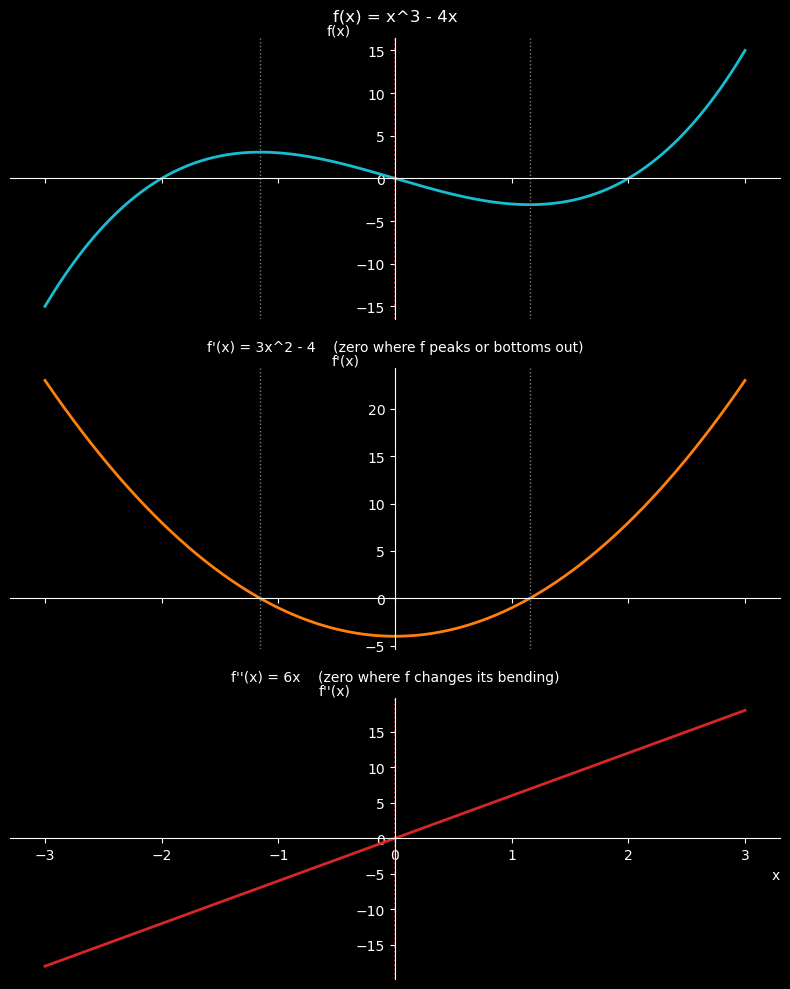

f' = 0 at x = +/- 1.1547   (a peak and a valley)
f'' = 0 at x = 0            (the inflection point)


In [3]:
xs = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(xs, f(xs), color="tab:cyan", lw=2)
axes[0].set_ylabel("f(x)", loc="top", rotation=0)
axes[0].set_title("f(x) = x^3 - 4x", pad=12)

axes[1].plot(xs, df(xs), color="tab:orange", lw=2)
axes[1].set_ylabel("f'(x)", loc="top", rotation=0)
axes[1].set_title("f'(x) = 3x^2 - 4    (zero where f peaks or bottoms out)", pad=12, fontsize=10)

axes[2].plot(xs, d2f(xs), color="tab:red", lw=2)
axes[2].set_ylabel("f''(x)", loc="top", rotation=0)
axes[2].set_xlabel("x", loc="right")
axes[2].set_title("f''(x) = 6x    (zero where f changes its bending)", pad=12, fontsize=10)

# mark the critical points on f and f', and the inflection on f and f''
crit = np.sqrt(4/3)
for ax in axes[:2]:
    for c in [-crit, crit]:
        ax.axvline(c, color="gray", ls=":", lw=1)
for ax in [axes[0], axes[2]]:
    ax.axvline(0, color="tab:red", ls=":", lw=1.2)

for ax in axes:
    center_axes(ax)
plt.tight_layout()
plt.show()

print(f"f' = 0 at x = +/- {crit:.4f}   (a peak and a valley)")
print(f"f'' = 0 at x = 0            (the inflection point)")

## 3. Concave up, concave down

Now shade the two regions on $f$ itself. On the left, $f'' < 0$ and the curve arches over like a dome.
On the right, $f'' > 0$ and it cups upward like a bowl. The changeover happens exactly at $x = 0$,
where $f'' = 0$ — the **inflection point**.

A memory aid that survives exams: **concave up holds water**.

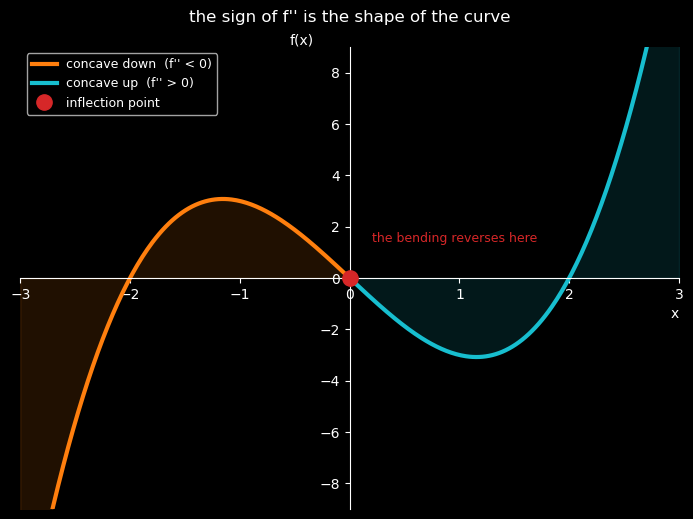

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6))

left, right = xs[xs <= 0], xs[xs >= 0]
ax.plot(left, f(left), color="tab:orange", lw=3, label="concave down  (f'' < 0)")
ax.plot(right, f(right), color="tab:cyan", lw=3, label="concave up  (f'' > 0)")
ax.fill_between(left, f(left), 0, color="tab:orange", alpha=0.13)
ax.fill_between(right, f(right), 0, color="tab:cyan", alpha=0.13)

ax.plot(0, f(0), "o", color="tab:red", markersize=11, zorder=5, label="inflection point")
ax.annotate("the bending reverses here", (0, 0), textcoords="offset points",
            xytext=(16, 26), color="tab:red", fontsize=9)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.set_xlim(-3, 3); ax.set_ylim(-9, 9)
ax.legend(loc="upper left", fontsize=9)
ax.set_title("the sign of f'' is the shape of the curve", pad=18)
plt.show()

In [5]:
# the same claim, checked rather than asserted: does the slope increase where f'' > 0?
print("f'' > 0 should mean the SLOPE is increasing. Sampling f' as x moves right:\n")
print("      x       f'(x)      f''(x)   slope is")
print("-" * 46)
for xv in [-2.0, -1.0, -0.5, 0.5, 1.0, 2.0]:
    trend = "increasing" if d2f(xv) > 0 else "decreasing"
    print(f"{xv:7.1f} {df(xv):11.3f} {d2f(xv):11.3f}   {trend}")

f'' > 0 should mean the SLOPE is increasing. Sampling f' as x moves right:

      x       f'(x)      f''(x)   slope is
----------------------------------------------
   -2.0       8.000     -12.000   decreasing
   -1.0      -1.000      -6.000   decreasing
   -0.5      -3.250      -3.000   decreasing
    0.5      -3.250       3.000   increasing
    1.0      -1.000       6.000   increasing
    2.0       8.000      12.000   increasing


## 4. The four combinations

$f'$ and $f''$ carry independent information, so all four sign combinations occur. This is the table
worth internalizing, because "the function is going down" and "the function is bending upward" are
different statements that can both be true.

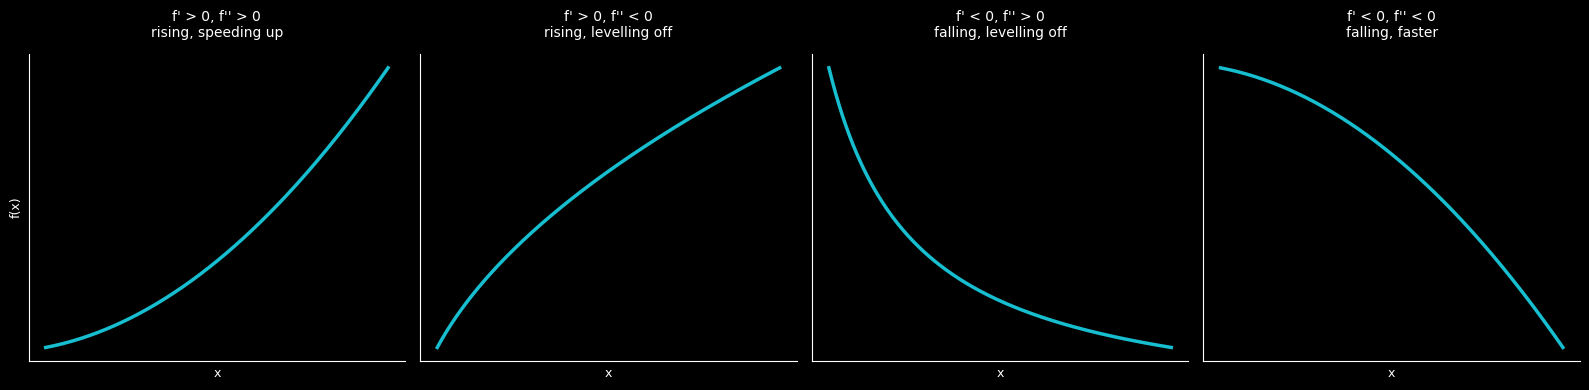

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cases = [
    ("f' > 0, f'' > 0\nrising, speeding up",   lambda t: t**2,           np.linspace(0.2, 1.5, 200)),
    ("f' > 0, f'' < 0\nrising, levelling off", lambda t: np.sqrt(t),     np.linspace(0.2, 2.5, 200)),
    ("f' < 0, f'' > 0\nfalling, levelling off", lambda t: 1/t,           np.linspace(0.5, 2.5, 200)),
    ("f' < 0, f'' < 0\nfalling, faster",       lambda t: -t**2,          np.linspace(0.2, 1.5, 200)),
]
for ax, (title, fn, dom) in zip(axes, cases):
    ax.plot(dom, fn(dom), color="tab:cyan", lw=2.5)
    ax.set_title(title, pad=12, fontsize=10)
    ax.set_xlabel("x", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("f(x)", fontsize=9)
plt.tight_layout()
plt.show()

The second and third panels are the ones people misread. Both are "levelling off," but one is rising
and one is falling — the difference is the sign of $f'$, not $f''$.

## 5. Summary

- $f''$ is the derivative of $f'$ — differentiate twice.
- **$f'' > 0$: concave up** (bowl, holds water), slope increasing. **$f'' < 0$: concave down** (dome),
  slope decreasing.
- An **inflection point** is where $f'' = 0$ *and* changes sign — the bending reverses.
- $f'$ and $f''$ are independent: a function can be falling while bending upward.
- Position / speed / acceleration is the same triple in everyday language.

Next: using $f'$ and $f''$ together to find and classify the highest and lowest points of a function —
**optimization** (`U3-5_Optimize-1_DerivativeTest`). But first, what to do when you only have data
points and no formula to differentiate (`U3-4_NumericalDerivatives-1_FiniteDifference`).